#### Dependencies

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

##### Read in the data

In [2]:
# read in the data
hmda_all = pd.read_csv('../data/hmda_all.csv') 
hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')

C:\Users\Cat\AppData\Local\Temp\ipykernel_26156\871124796.py:3: DtypeWarning: Columns (26,27,28,29,30,31,32,33,43,44,78,80) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')


## Logistic Regression Models:

### Use the NON Filtered Dataset

### Applicant Ethnicity AE

In [3]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino

In [4]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~
                                            ae_values_1 + ae_values_11 + ae_values_12 + 
                                            ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                           data=hmda_all_nf)

In [5]:
res_ae = model_logit_ae.fit(maxiter=1000, disp=False)

In [6]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.194321
ae_values_11    0.934447
ae_values_12    0.820520
ae_values_13    0.786167
ae_values_14    0.778521
dtype: float64

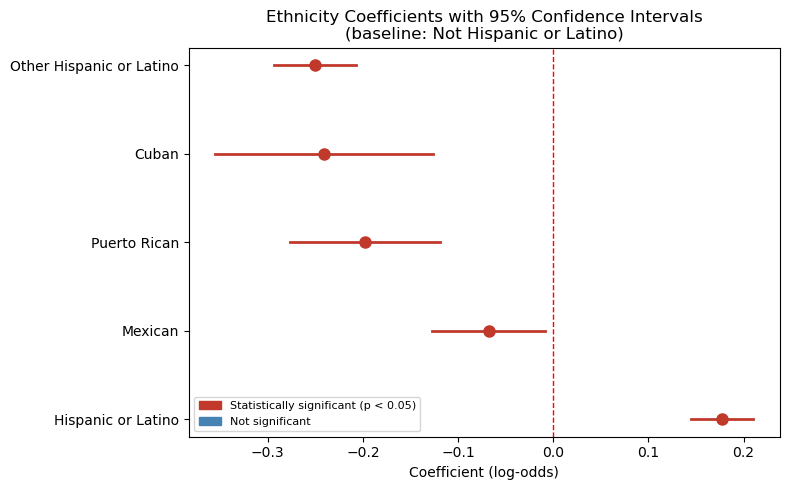

In [7]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

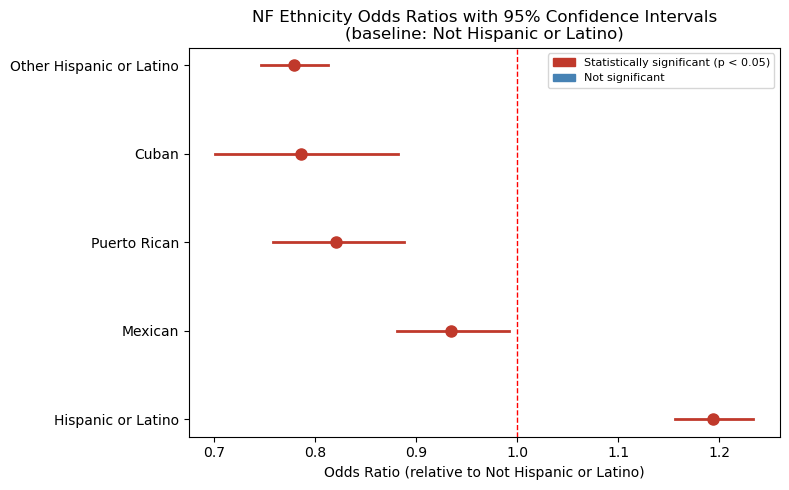

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino
#### Include open_end_line_of_credit

In [9]:
model_logit_ae_nf_oelc = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_11 + ae_values_12 + ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio + 
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(open_end_line_of_credit) + 
                                            applicant_age + 
                                            gender""", 
                              data=hmda_all_nf)

In [10]:
res_ae = model_logit_ae_nf_oelc.fit(maxiter=1000, disp=False)

C:\Users\Cat\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [11]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.173584
ae_values_11    0.912024
ae_values_12    0.825124
ae_values_13    0.793829
ae_values_14    0.757116
dtype: float64

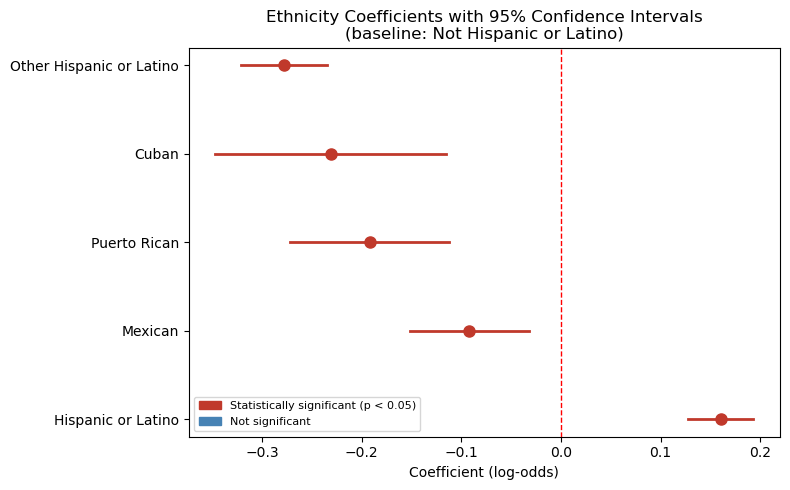

In [12]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

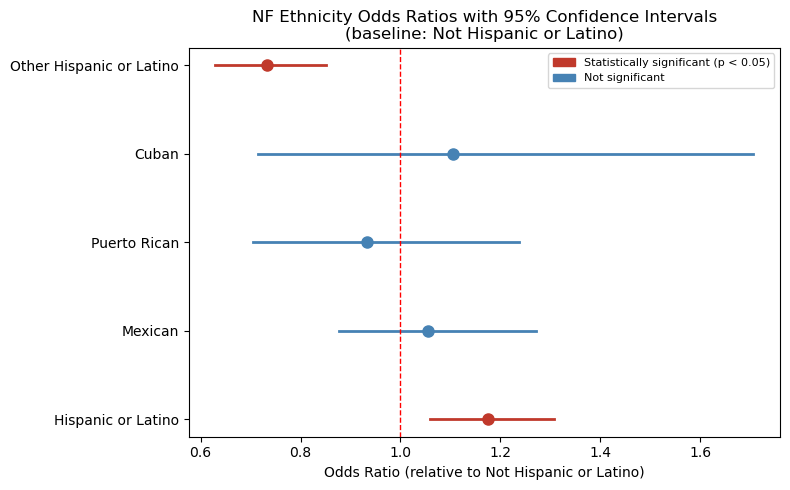

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

#### Create Hispanic vs. Not Hispanic without OELC

In [30]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

In [33]:
hmda_hispanic_not_hispanic = hmda_all_nf[~hmda_all_nf['applicant_ethnicity-1'].isin([3, 4])]

In [36]:
# hmda columns
ethnicity_cols = ['applicant_ethnicity-1', 'applicant_ethnicity-2', 'applicant_ethnicity-3',
                  'applicant_ethnicity-4', 'applicant_ethnicity-5']

hispanic_nums = [1, 11, 12, 13, 14]

# indicator columns for each hispanic subcategory --> one per code
for num in hispanic_nums:
    hmda_hispanic_not_hispanic[f'ae_values_{num}'] = (hmda_hispanic_not_hispanic[ethnicity_cols] == num).any(axis=1)

# overall hispanic indicator
hmda_hispanic_not_hispanic['is_hispanic'] = hmda_hispanic_not_hispanic[[f'ae_values_{num}' for num in hispanic_nums]].any(axis=1)

# not hispanic indicator
hmda_hispanic_not_hispanic['not_hispanic'] = hmda_hispanic_not_hispanic['ae_values_2']

C:\Users\Cat\AppData\Local\Temp\ipykernel_26156\2506755687.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_hispanic_not_hispanic[f'ae_values_{num}'] = (hmda_hispanic_not_hispanic[ethnicity_cols] == num).any(axis=1)
C:\Users\Cat\AppData\Local\Temp\ipykernel_26156\2506755687.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_hispanic_not_hispanic[f'ae_values_{num}'] = (hmda_hispanic_not_hispanic[ethnicity_cols] == num).any(axis=1)
C:\Users\Cat\AppData\Local\Temp\ipykernel_26156\2506755687.py:9:

In [38]:
model_logit_ae_h = smf.logit(formula = """
                                        approved_originated_or_denied ~ 
                                            is_hispanic + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                             data=hmda_hispanic_not_hispanic)

In [39]:
res_ae_h = model_logit_ae_h.fit(maxiter=1000, disp=False)

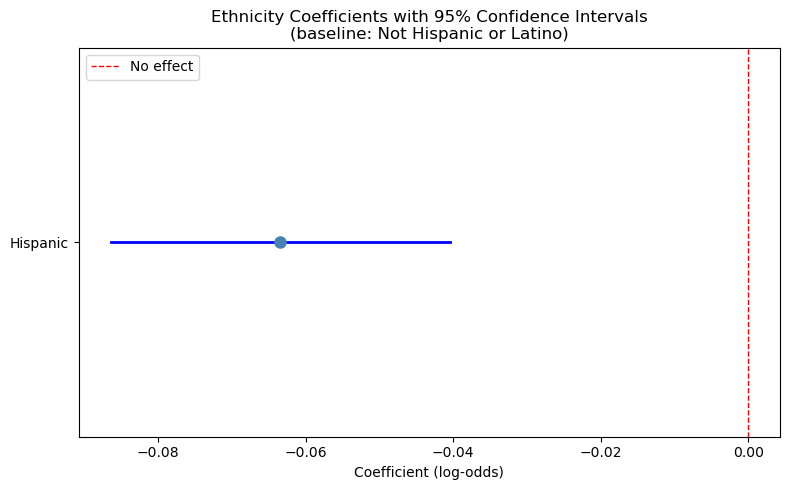

In [40]:
# pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['is_hispanic[T.True]']
labels = ['Hispanic']

coefs_h = res_ae_h.params[ethnicity_vars]
conf_h = res_ae_h.conf_int().loc[ethnicity_vars]

# plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_h.loc[var, 0], conf_h.loc[var, 1]], [i, i], color='blue', linewidth=2)
    ax.plot(coefs_h[var], i, 'o', color='steelblue', markersize=8)

# reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_hispanic_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

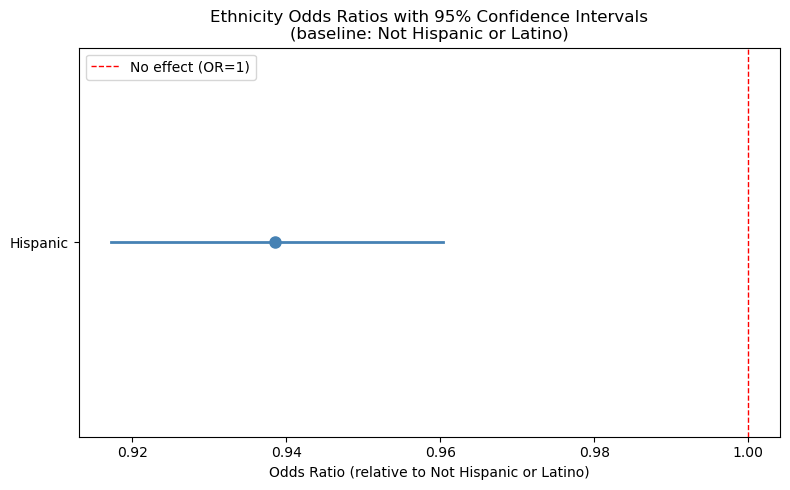

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs_h)
conf_or = np.exp(conf_h)

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color='steelblue', markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_hispanic_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

### Use the Filtered Dataset for the same Logistic Regression:

### Applicant Ethnicity AE

In [14]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino

In [15]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~
                                            ae_values_1 + ae_values_11 + ae_values_12 + 
                                            ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                           data=hmda_all)

In [16]:
res_ae = model_logit_ae.fit(maxiter=1000, disp=False)

In [17]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.176211
ae_values_11    1.055665
ae_values_12    0.932897
ae_values_13    1.104862
ae_values_14    0.732207
dtype: float64

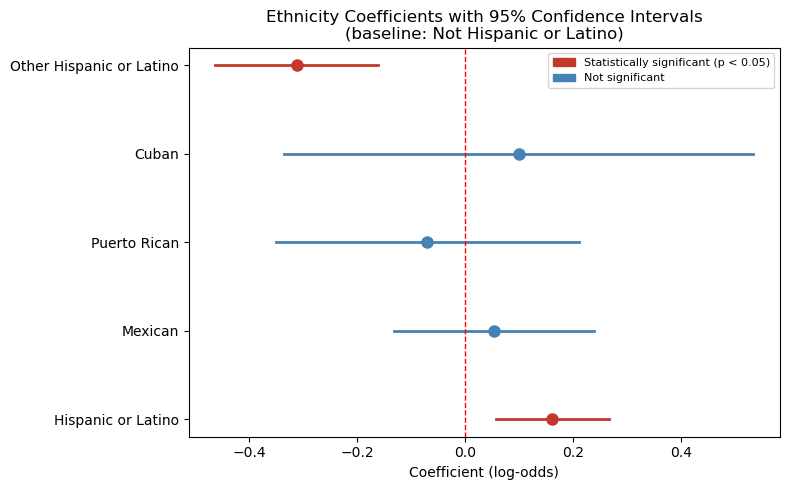

In [18]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

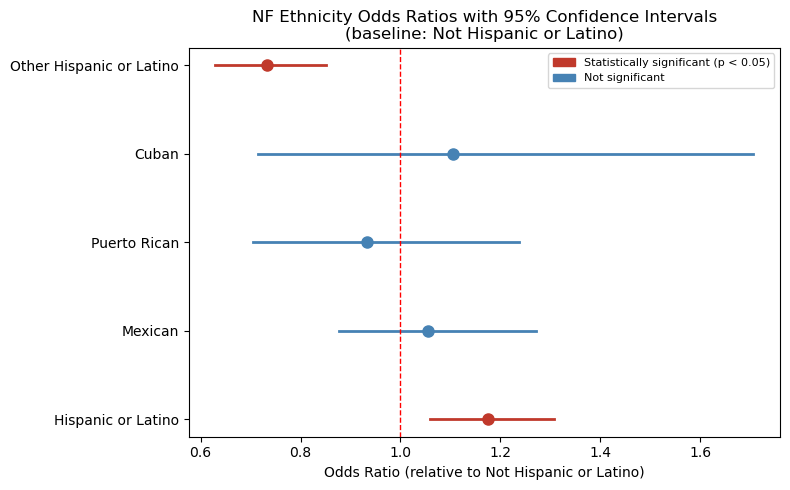

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino
#### Include open_end_line_of_credit

In [21]:
model_logit_ae_oelc = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_11 + ae_values_12 + ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio + 
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(open_end_line_of_credit) + 
                                            applicant_age + 
                                            gender""", 
                              data=hmda_all)

In [22]:
res_ae = model_logit_ae_oelc.fit(maxiter=1000, disp=False)

In [23]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.176211
ae_values_11    1.055665
ae_values_12    0.932897
ae_values_13    1.104862
ae_values_14    0.732207
dtype: float64

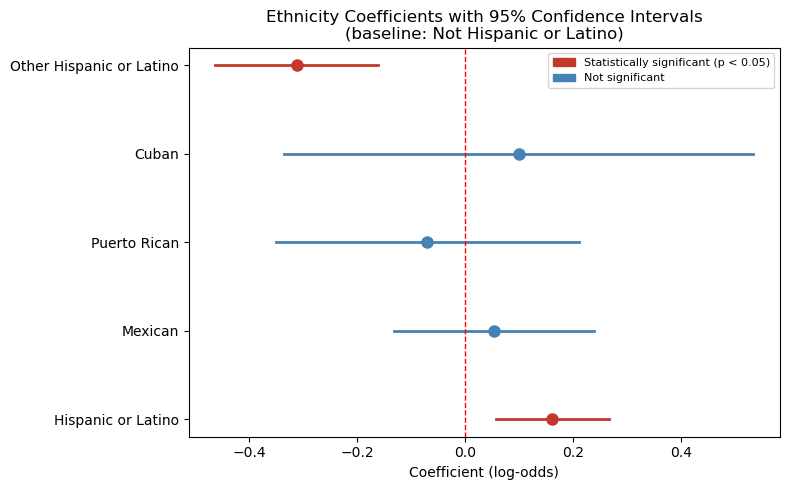

In [24]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

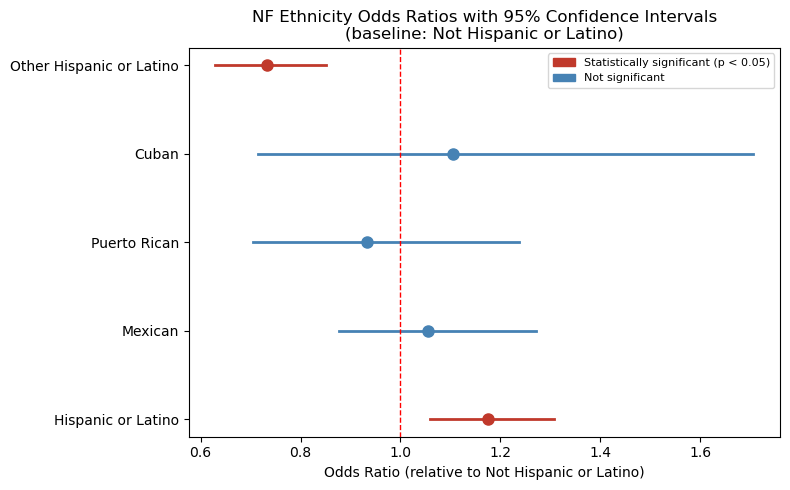

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

#### Create Hispanic vs. Not Hispanic without OELC

In [44]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

In [45]:
hmda_hispanic_not_hispanic_filtered = hmda_all[~hmda_all['applicant_ethnicity-1'].isin([3, 4])]

In [46]:
# hmda columns
ethnicity_cols = ['applicant_ethnicity-1', 'applicant_ethnicity-2', 'applicant_ethnicity-3',
                  'applicant_ethnicity-4', 'applicant_ethnicity-5']

hispanic_nums = [1, 11, 12, 13, 14]

# indicator columns for each hispanic subcategory --> one per code
for num in hispanic_nums:
    hmda_hispanic_not_hispanic_filtered[f'ae_values_{num}'] = (hmda_hispanic_not_hispanic_filtered[ethnicity_cols] == num).any(axis=1)

# overall hispanic indicator
hmda_hispanic_not_hispanic_filtered['is_hispanic'] = hmda_hispanic_not_hispanic_filtered[[f'ae_values_{num}' for num in hispanic_nums]].any(axis=1)

# not hispanic indicator
hmda_hispanic_not_hispanic_filtered['not_hispanic'] = hmda_hispanic_not_hispanic_filtered['ae_values_2']

C:\Users\Cat\AppData\Local\Temp\ipykernel_26156\1036888616.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_hispanic_not_hispanic_filtered[f'ae_values_{num}'] = (hmda_hispanic_not_hispanic_filtered[ethnicity_cols] == num).any(axis=1)
C:\Users\Cat\AppData\Local\Temp\ipykernel_26156\1036888616.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_hispanic_not_hispanic_filtered[f'ae_values_{num}'] = (hmda_hispanic_not_hispanic_filtered[ethnicity_cols] == num).any(axis=1)
C:\Users\Cat\AppData\Local\T

In [47]:
model_logit_ae_h_f = smf.logit(formula = """
                                        approved_originated_or_denied ~ 
                                            is_hispanic + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                             data=hmda_hispanic_not_hispanic_filtered)

In [48]:
res_ae_h = model_logit_ae_h_f.fit(maxiter=1000, disp=False)

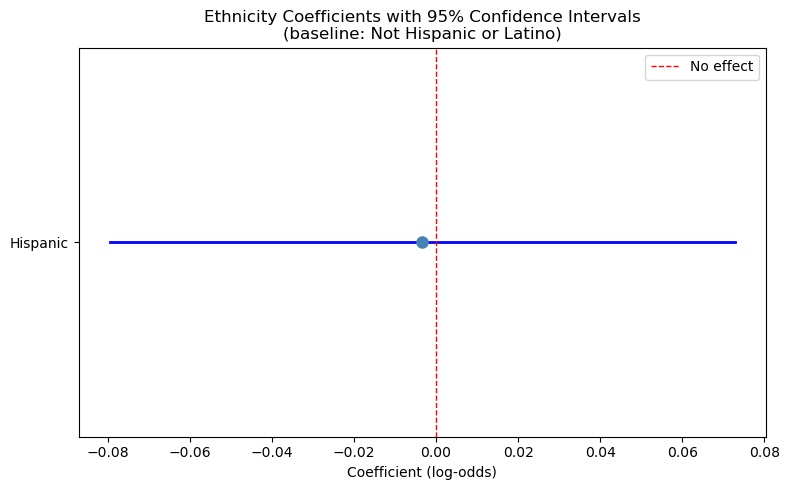

In [49]:
# pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['is_hispanic[T.True]']
labels = ['Hispanic']

coefs_h = res_ae_h.params[ethnicity_vars]
conf_h = res_ae_h.conf_int().loc[ethnicity_vars]

# plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_h.loc[var, 0], conf_h.loc[var, 1]], [i, i], color='blue', linewidth=2)
    ax.plot(coefs_h[var], i, 'o', color='steelblue', markersize=8)

# reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/App_Ethnicity_hispanic_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

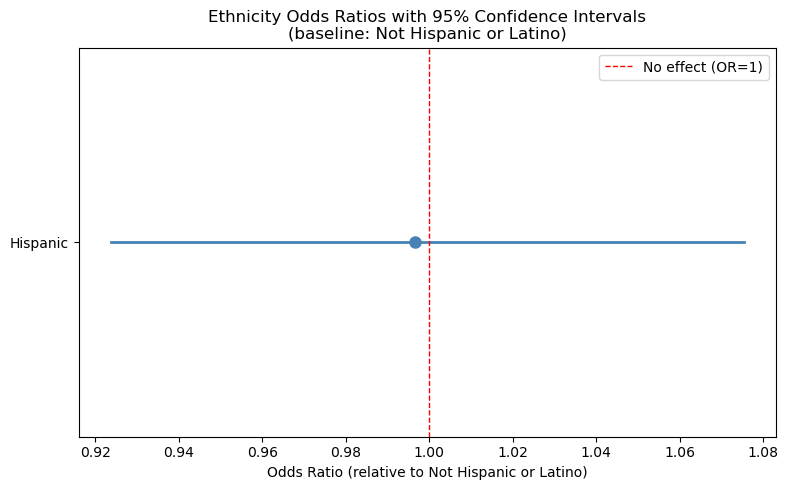

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs_h)
conf_or = np.exp(conf_h)

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color='steelblue', markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/App_Ethnicity_hispanic_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()